`conda activate r_python`

In [1]:
suppressPackageStartupMessages({
    library(ggplot2)
    # library(scater)
    library(Seurat)
    library(dplyr)
    library(tibble)
    library(stringr)
    library(dittoSeq)
    library(future)
    library(data.table)
    plan("multicore", workers = 12)
    options(future.globals.maxSize = 1000 * 1024^5)
    options(stringsAsFactors = FALSE)
    set.seed(123)
})

In [2]:
dmg <- readRDS('../data/rna_dmg_atlas_scglue_embbeding.rds')
dmg

An object of class Seurat 
19248 features across 397794 samples within 1 assay 
Active assay: RNA (19248 features, 2000 variable features)
 2 dimensional reductions calculated: pca, umap

### Reference mapping

In [5]:
# taken from Azimuth reference (Bakken et al, bioRxiv 2020)
ascites <- readRDS('/hpc/pmc_stunnenberg/cruiz/scRNA/analysis/pmc_patients/dipg_ascitis/deep_sequencing/for_publication/data/ascites/dmg_ascites_prettx.rds')
ascites

An object of class Seurat 
44017 features across 21704 samples within 2 assays 
Active assay: SCT (21525 features, 3000 variable features)
 1 other assay present: RNA
 2 dimensional reductions calculated: mnn, umap

In [9]:
reference = dmg

In [10]:
anchors <- FindTransferAnchors(
  reference = reference,
  query = ascites,
  features = rownames(reference[["RNA"]]),
  normalization.method = "LogNormalize",
  reference.reduction = "pca",
  dims = 1:50
)

Warning message:
“2877 features of the features specified were not present in both the reference query assays. 
Continuing with remaining 16371 features.”
Projecting cell embeddings

Finding neighborhoods

Finding anchors

	Found 3906 anchors

Filtering anchors

	Retained 875 anchors



`Map Query` functions run separately

In [11]:
ascites <- TransferData(
  anchorset = anchors, 
  reference = reference,
  query = ascites,
  refdata = list(
      dmg.atlas.lvl_1 = 'lvl_1',
      dmg.atlas.lvl_2 = 'lvl_2',
      dmg.atlas.lvl_3 = 'lvl_3',
      dmg.atlas.lvl_4 = 'lvl_4',
      dmg.atlas.lvl_4_coarse = 'lvl_4_coarse',
      dmg.atlas.lvl_5 = 'lvl_5'
      
  ),
)

Finding integration vectors

Finding integration vector weights

Predicting cell labels

Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from predictionscoredmg.atlas.lvl_1_ to predictionscoredmgatlaslvl1_”
Predicting cell labels

Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from predictionscoredmg.atlas.lvl_2_ to predictionscoredmgatlaslvl2_”
Predicting cell labels

Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Keys should be one or more alphanumeric characters followed by an underscore, setting key from predictionscoredmg.atlas.lvl_3_ to predictionscoredmgatlaslvl3_”
Predicting cell labels

Warning message:
“Feature names cannot have underscores ('_'), replacing with dashes ('-')”
Warning message:
“Keys should

In [12]:
ascites <- IntegrateEmbeddings(
  anchorset = anchors,
  reference = reference,
  query = ascites, 
  new.reduction.name = "ref.pca"
)


Integrating dataset 2 with reference dataset

Finding integration vectors

Integrating data

Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via the L'Ecuyer-CMRG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore".”


In [14]:
ascites <- ProjectUMAP(
  query = ascites, 
  query.reduction = "ref.pca", 
  reference = reference, 
  reference.reduction = "pca", 
  reduction.model = "umap"
)

Computing nearest neighbors

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
Running UMAP projection

18:34:42 Read 21704 rows

18:34:42 Processing block 1 of 1

18:34:42 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

18:34:46 Initializing by weighted average of neighbor coordinates using 1 thread

18:34:46 Commencing optimization for 67 epochs, with 651120 positive edges

18:34:52 Finished



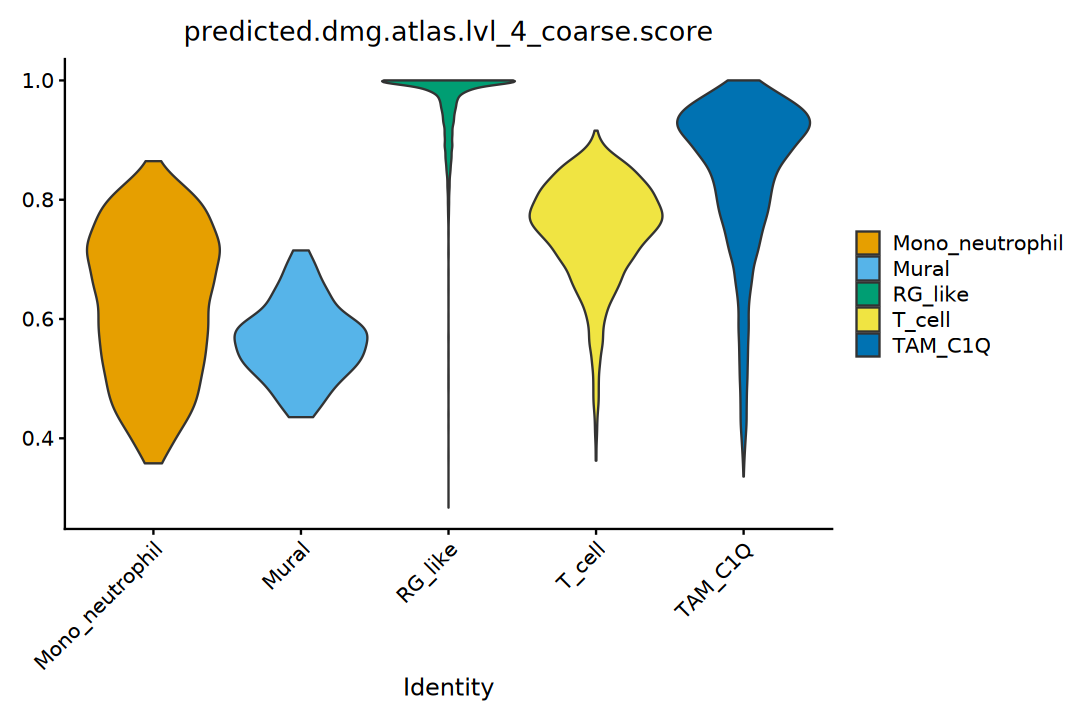

In [19]:
options(repr.plot.height = 6, repr.plot.width = 9)
VlnPlot(ascites, features = "predicted.dmg.atlas.lvl_4_coarse.score", 
        group.by = 'predicted.dmg.atlas.lvl_4_coarse', cols = dittoColors(), pt.size = 0) 

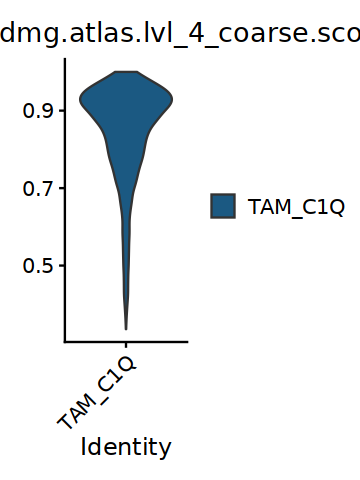

In [14]:
options(repr.plot.height = 4, repr.plot.width = 3)
VlnPlot(subset(ascites, predicted.dmg.atlas.lvl_4_coarse=='TAM_C1Q'), features = "predicted.dmg.atlas.lvl_4_coarse.score", 
        group.by = 'predicted.dmg.atlas.lvl_4_coarse', cols='#1b5982', pt.size=0) 

In [15]:
ggsave('../figures/prediction_ascites_tams_pDG_atlas.pdf', height = 4, width = 3)